In [29]:
import matplotlib.pyplot as plt
import numpy as np
import mitsuba as mi
import pyvista as pv
import sionna
import tensorflow as tf
from sionna.rt import load_scene, Transmitter, Receiver, PlanarArray, PathSolver, Camera
from scipy.optimize import minimize
import h5py
from pathlib import Path
import sys

In [30]:
# ============================================================================
# SYSTEM PARAMETERS AND CLASS DEFINITIONS
# ============================================================================

# --- SYSTEM PARAMETERS ---
CARRIER_FREQUENCY = 2.412e9  
BANDWIDTH = 20e6           
NUM_SUBCARRIERS = 64       
SUBCARRIER_SPACING = BANDWIDTH / NUM_SUBCARRIERS
WAVELENGTH = 3e8 / CARRIER_FREQUENCY
NUM_ANTENNAS_RX = 4
subcarrier_indices = np.arange(NUM_SUBCARRIERS)
subcarriers = CARRIER_FREQUENCY + (subcarrier_indices - NUM_SUBCARRIERS/2) * SUBCARRIER_SPACING
rng = np.random.default_rng()

# --- Define subcarrier frequencies ---
subcarrier_indices = np.arange(NUM_SUBCARRIERS)
subcarriers = CARRIER_FREQUENCY + (subcarrier_indices - NUM_SUBCARRIERS/2) * SUBCARRIER_SPACING

# --- Import for peak detection ---
from scipy.signal import find_peaks

class CSIAngleEstimator:
    """Angle of Arrival estimator using MUSIC algorithm with planar array support"""
    def __init__(self, num_antennas, wavelength, rx_array=None, array_type='planar'):
        # Initial setup
        self.num_antennas = num_antennas 
        self.wavelength = wavelength
        self.antenna_spacing = wavelength / 2
        self.k = 2 * np.pi / wavelength
        self.array_type = array_type
        
        # If Sionna RX object is provided, extract actual antenna positions
        if rx_array is not None:
            try:
                # 1. Get positions, using self.wavelength for correct scaling (m).
                # ant_positions shape is (3, 4): [X, Y, Z] rows, [Ant 0..3] columns
                ant_positions_raw = rx_array.positions(self.wavelength).numpy()
                
                # 2. Transpose the matrix to the standard (N_antennas, N_dimensions) shape: (4, 3)
                ant_positions = ant_positions_raw.T
                
                # --- Dynamic Antenna Count ---
                # The number of rows is the actual number of unique antennas (4)
                actual_num_antennas = ant_positions.shape[0]
                
                print(f"\n  Extracted Sionna RX Array Geometry:")
                print(f"    Raw shape: {ant_positions_raw.shape} (Dimensions, Antennas)")
                print(f"    Transposed shape: {ant_positions.shape} (Antennas, Dimensions)")
                print(f"    Number of antennas: {actual_num_antennas}")
                
                # Update the internal antenna count property
                if actual_num_antennas != num_antennas:
                    print(f"Expected antenna count ({num_antennas}) vs. actual geometry count ({actual_num_antennas}). Adjusting estimator size.")
                self.num_antennas = actual_num_antennas

                # 3. Extract x, y, z positions from the columns of the transposed matrix
                self.pos_x = ant_positions[:, 0]
                self.pos_y = ant_positions[:, 1]
                self.pos_z = ant_positions[:, 2] 
                
                print(f"    Antenna positions (relative to RX center):")
                for i, pos in enumerate(ant_positions):
                    print(f"      Ant {i}: x={pos[0]:.4f}, y={pos[1]:.4f}, z={pos[2]:.4f}")
                
                print(f"    Using X: {self.pos_x}")
                print(f"    Using Y: {self.pos_y}")
                print(f"    Using Z: {self.pos_z}")
                
            except Exception as e:
                print(f"  Could not extract Sionna array positions: {e}")
                print(f"  Falling back to default geometry")
                self._set_default_geometry(num_antennas, array_type)
        else:
            self._set_default_geometry(num_antennas, array_type)
    
    def _set_default_geometry(self, num_antennas, array_type):
        """Set default array geometry (fallback)"""
        if array_type == 'planar' and num_antennas == 4:
            self.pos_x = np.array([0, 1, 0, 1]) * self.antenna_spacing
            self.pos_z = np.array([0, 0, 1, 1]) * self.antenna_spacing
            self.pos_y = np.zeros(num_antennas)
        else:
            self.pos_x = np.arange(num_antennas) * self.antenna_spacing
            self.pos_z = np.zeros(num_antennas)
            self.pos_y = np.zeros(num_antennas)
    
    def steering_vector(self, azimuth, elevation=0):
        """
        3D steering vector using actual antenna positions.
        
        Args:
            azimuth: Angle in X-Z plane (or appropriate plane based on actual geometry)
            elevation: Angle from horizontal plane toward Y axis
        """
        # Use actual antenna positions (now extracted from Sionna)
        phase = self.k * (
            self.pos_x * np.cos(azimuth) * np.cos(elevation) + 
            self.pos_z * np.sin(azimuth) * np.cos(elevation) +
            self.pos_y * np.sin(elevation)
        )
        return np.exp(1j * phase)
    
    def estimate_aoa_music(self, csi_matrix, num_sources=1, return_spectrum=False):
        """
        Estimate azimuth angle of arrival using MUSIC algorithm.
        Assumes elevation ≈ 0 (signals in horizontal X-Z plane).
        
        Args:
            csi_matrix: [Antennas, Subcarriers] CSI matrix
            num_sources: Number of signal sources (typically 1)
            return_spectrum: If True, return full MUSIC spectrum
            
        Returns:
            aoa_estimate: Estimated azimuth angle in radians [-π, π]
            spectrum (optional): Full MUSIC pseudo-spectrum
        """
        M = csi_matrix.shape[0]  # Number of antennas
        N = csi_matrix.shape[1]  # Number of subcarriers
        
        # Forward covariance
        R_forward = csi_matrix @ csi_matrix.conj().T / N
        
        # Backward covariance (for forward-backward averaging)
        J = np.fliplr(np.eye(M))  # Exchange matrix
        R_backward = J @ R_forward.conj() @ J
        
        # Forward-backward averaged covariance (more robust, better rank)
        R = (R_forward + R_backward) / 2
        
        eigenvalues, eigenvectors = np.linalg.eigh(R)
        idx = eigenvalues.argsort()[::-1]
        noise_subspace = eigenvectors[:, idx[num_sources:]]
        
        # Note: After F-B averaging, we still have M×M covariance
        # So noise_subspace is M × (M-num_sources)
        
        # Extended search range: full 360° (-π to π) in X-Z plane
        angles = np.linspace(-np.pi+5, np.pi-5, 360)
        spectrum = np.zeros(len(angles))
        
        for i, angle in enumerate(angles):
            # Steering vector for azimuth in X-Z plane (elevation = 0)
            # Must match dimension M (number of antennas)
            a = self.steering_vector(angle, elevation=0)
            
            # Ensure a is M×1 and noise_subspace is M×(M-num_sources)
            if len(a) != noise_subspace.shape[0]:
                raise ValueError(f"Steering vector size {len(a)} doesn't match noise subspace {noise_subspace.shape[0]}")
            
            spectrum[i] = 1.0 / (np.abs(
                a.conj() @ noise_subspace @ noise_subspace.conj().T @ a
            ) + 1e-10)
        
        peak_idx = np.argmax(spectrum)
        aoa_estimate = angles[peak_idx]
        
        if return_spectrum:
            return aoa_estimate, spectrum
        else:
            return aoa_estimate

class FTMRangeEstimator:
    """Range estimator from CSI phase slope (FTM mechanism) with first-arrival detection"""
    def __init__(self, speed_of_light=3e8):
        self.c = speed_of_light
    
    def estimate_range_from_phase(self, csi_subcarriers, subcarrier_spacing):
        phase = np.unwrap(np.angle(csi_subcarriers))
        subcarrier_idx = np.arange(len(phase))
        coeffs = np.polyfit(subcarrier_idx * subcarrier_spacing, phase, 1)
        phase_slope = coeffs[0]
        toa = -phase_slope / (2 * np.pi)
        return abs(self.c * toa)  # One-way delay from CSI, no /2
    
    def estimate_range_from_cir(self, delays, amplitudes, power_threshold_db=-20):
        """
        First-arrival ToA ranging: uses first path with significant power (LoS)
        instead of strongest path which could be NLOS reflection.
        """
        powers = np.abs(amplitudes) ** 2
        max_power = np.max(powers)
        threshold = max_power * (10 ** (power_threshold_db / 10))
        
        # Find first path above threshold (likely LoS)
        valid_mask = powers > threshold
        if np.any(valid_mask):
            valid_delays = delays[valid_mask]
            first_arrival_delay = np.min(valid_delays)
        else:
            # Fallback to minimum delay
            first_arrival_delay = np.min(delays)
        
        return self.c * first_arrival_delay


class BilaterationSolver:
    """Hybrid localization using range and angle (Weighted Least Squares)"""
    @staticmethod
    def hybrid_localization(anchor_positions, ranges, angles, distance_std=0.5, angle_std=0.1):
        # Ensure anchor_positions is a 2D array
        anchor_positions = np.asarray(anchor_positions)
        if anchor_positions.ndim == 1:
            anchor_positions = anchor_positions.reshape(1, -1)
        
        # Ensure ranges and angles are 1D arrays
        ranges = np.asarray(ranges).flatten()
        angles = np.asarray(angles).flatten()
        
        num_anchors = len(anchor_positions)
        distance_weight = 1 / (distance_std**2)
        angle_weight = 1 / (angle_std**2)
        
        def objective(pos):
            # Ensure pos is 1D
            pos = np.asarray(pos).flatten()
            
            # 1. Distance Errors (Ranging)
            error_d = 0.0
            for i in range(num_anchors):
                dist = np.linalg.norm(pos - anchor_positions[i])
                error_d += distance_weight * (ranges[i] - dist)**2
            
            # 2. Angle Errors (AoA)
            error_a = 0.0 
            
            for i in range(num_anchors):
                if not np.isnan(angles[i]):
                    pos_x = float(pos[0])
                    pos_z = float(pos[2])  # ← Use Z instead of Y
                    anchor_x = float(anchor_positions[i, 0])
                    anchor_z = float(anchor_positions[i, 2])  # ← Use Z instead of Y
                    
                    # Calculate direction FROM ANCHOR TO TARGET in X-Z plane
                    dir_x = pos_x - anchor_x
                    dir_z = pos_z - anchor_z  # ← Changed from dir_y
                    
                    estimated_angle = np.arctan2(dir_z, dir_x)  # ← Azimuth in X-Z plane
                    angle_diff = float(angles[i]) - estimated_angle
                    
                    # Normalize angle difference to [-pi, pi]
                    angle_diff = np.arctan2(np.sin(angle_diff), np.cos(angle_diff))
                    error_a += angle_weight * (angle_diff**2)
            
            # Total Error
            total_error = error_d + error_a
            return float(total_error)
        
        # Initial guess: mean of anchor positions - ENSURE 1D
        x0 = np.mean(anchor_positions, axis=0).flatten()
        
        # Debug: verify x0 is 1D
        if x0.ndim != 1:
            raise ValueError(f"x0 has {x0.ndim} dimensions, shape {x0.shape}. Expected 1D array.")
        
        result = minimize(objective, x0, method='BFGS') 
        return result.x


# ============================================================================
# ENHANCED NLOS MITIGATION CLASSES
# ============================================================================

class EnhancedFTMRangeEstimator:
    """Range estimator with advanced NLOS detection and mitigation"""
    def __init__(self, speed_of_light=3e8):
        self.c = speed_of_light
    
    def estimate_range_from_cir(self, delays, amplitudes, power_threshold_db=-20):
        """Basic first-arrival ToA ranging (for compatibility)"""
        powers = np.abs(amplitudes) ** 2
        max_power = np.max(powers)
        threshold = max_power * (10 ** (power_threshold_db / 10))
        
        valid_mask = powers > threshold
        if np.any(valid_mask):
            valid_delays = delays[valid_mask]
            first_arrival_delay = np.min(valid_delays)
        else:
            first_arrival_delay = np.min(delays)
        
        return self.c * first_arrival_delay
    
    def detect_nlos(self, delays, amplitudes, kurtosis_threshold=3.0, rician_k_threshold=2.0):
        """
        NLOS detection using statistical channel characteristics.
        Returns: (is_nlos, nlos_probability, metrics)
        """
        powers = np.abs(amplitudes) ** 2
        powers_normalized = powers / (np.sum(powers) + 1e-12)
        
        # 1. Kurtosis-based detection (NLOS has higher kurtosis)
        mean_power = np.mean(powers)
        std_power = np.std(powers) + 1e-12
        kurtosis = np.mean((powers - mean_power)**4) / (std_power**4)
        
        # 2. Rician K-factor estimation (LOS has higher K)
        sorted_powers = np.sort(powers)[::-1]
        if len(sorted_powers) > 1:
            k_factor = sorted_powers[0] / (np.sum(sorted_powers[1:]) + 1e-12)
        else:
            k_factor = np.inf
        
        # 3. RMS delay spread (NLOS has larger spread)
        mean_delay = np.sum(delays * powers_normalized)
        rms_delay_spread = np.sqrt(np.sum((delays - mean_delay)**2 * powers_normalized))
        
        # 4. First-to-strongest path delay difference
        power_threshold = powers.max() * 0.01
        valid_indices = np.where(powers > power_threshold)[0]
        if len(valid_indices) > 0:
            first_path_idx = valid_indices[np.argmin(delays[valid_indices])]
        else:
            first_path_idx = np.argmin(delays)
        strongest_path_idx = np.argmax(powers)
        delay_diff = abs(delays[strongest_path_idx] - delays[first_path_idx])
        
        # NLOS probability based on metrics
        nlos_score = 0.0
        if kurtosis > kurtosis_threshold:
            nlos_score += 0.3
        if k_factor < rician_k_threshold:
            nlos_score += 0.3
        if delay_diff > 10e-9:  # >10ns difference suggests NLOS
            nlos_score += 0.4
        
        is_nlos = nlos_score > 0.5
        
        return is_nlos, nlos_score, {
            'kurtosis': kurtosis,
            'k_factor': k_factor,
            'rms_delay_spread': rms_delay_spread,
            'delay_diff': delay_diff
        }
    
    def estimate_range_nlos_mitigated(self, delays, amplitudes, power_threshold_db=-15):
        """
        NLOS-mitigated range estimation using multiple techniques.
        """
        powers = np.abs(amplitudes) ** 2
        
        # 1. Detect NLOS condition
        is_nlos, nlos_prob, metrics = self.detect_nlos(delays, amplitudes)
        
        # 2. First-arrival detection (baseline)
        threshold = np.max(powers) * (10 ** (power_threshold_db / 10))
        valid_mask = powers > threshold
        
        if np.any(valid_mask):
            valid_delays = delays[valid_mask]
            first_arrival_delay = np.min(valid_delays)
        else:
            first_arrival_delay = np.min(delays)
        
        # 3. If NLOS detected, apply additional mitigation
        if is_nlos:
            # Use lower threshold to catch weaker LOS component
            stricter_threshold = np.max(powers) * (10 ** (-25 / 10))
            strict_mask = powers > stricter_threshold
            if np.any(strict_mask):
                first_arrival_delay = np.min(delays[strict_mask])
            
            # Apply NLOS bias correction (empirical: NLOS adds ~0.5-2m positive bias)
            nlos_bias_correction = 0.5 * nlos_prob  # Scale by NLOS probability
            range_estimate = self.c * first_arrival_delay - nlos_bias_correction
        else:
            range_estimate = self.c * first_arrival_delay
        
        return max(0, range_estimate), is_nlos, nlos_prob


class EnhancedAoAEstimator:
    """AoA estimator with NLOS mitigation using spatial smoothing and robust peak detection"""
    def __init__(self, num_antennas, wavelength, rx_array=None, array_type='planar'):
        self.num_antennas = num_antennas
        self.wavelength = wavelength
        self.antenna_spacing = wavelength / 2
        self.k = 2 * np.pi / wavelength
        self.array_type = array_type
        
        # If Sionna RX object is provided, extract actual antenna positions
        if rx_array is not None:
            try:
                ant_positions_raw = rx_array.positions(self.wavelength).numpy()
                ant_positions = ant_positions_raw.T
                actual_num_antennas = ant_positions.shape[0]
                
                if actual_num_antennas != num_antennas:
                    print(f"  EnhancedAoAEstimator: Adjusting antenna count from {num_antennas} to {actual_num_antennas}")
                self.num_antennas = actual_num_antennas
                
                self.pos_x = ant_positions[:, 0]
                self.pos_y = ant_positions[:, 1]
                self.pos_z = ant_positions[:, 2]
                
            except Exception as e:
                print(f"  EnhancedAoAEstimator: Could not extract Sionna positions: {e}, using default")
                self._set_default_geometry(num_antennas, array_type)
        else:
            self._set_default_geometry(num_antennas, array_type)
    
    def _set_default_geometry(self, num_antennas, array_type):
        """Set default array geometry (fallback)"""
        if array_type == 'planar' and num_antennas == 4:
            self.pos_x = np.array([0, 1, 0, 1]) * self.antenna_spacing
            self.pos_z = np.array([0, 0, 1, 1]) * self.antenna_spacing
            self.pos_y = np.zeros(num_antennas)
        else:
            self.pos_x = np.arange(num_antennas) * self.antenna_spacing
            self.pos_z = np.zeros(num_antennas)
            self.pos_y = np.zeros(num_antennas)
    
    def steering_vector(self, azimuth, elevation=0):
        """3D steering vector using actual antenna positions"""
        phase = self.k * (
            self.pos_x * np.cos(azimuth) * np.cos(elevation) + 
            self.pos_z * np.sin(azimuth) * np.cos(elevation) +
            self.pos_y * np.sin(elevation)
        )
        return np.exp(1j * phase)
    
    def estimate_aoa_music_nlos_robust(self, csi_matrix, delays=None, amplitudes=None, 
                                        num_sources=1, return_spectrum=False):
        """
        NLOS-robust MUSIC with spatial smoothing and multipath-aware processing.
        """
        M = csi_matrix.shape[0]  # Number of antennas
        N = csi_matrix.shape[1]  # Number of subcarriers
        
        # 1. Spatial smoothing for decorrelation (helps with coherent multipath)
        if M >= 3:
            L = max(2, M - 1)  # Subarray size
            R_smooth = np.zeros((L, L), dtype=complex)
            num_subarrays = M - L + 1
            
            for i in range(num_subarrays):
                sub_csi = csi_matrix[i:i+L, :]
                R_sub = sub_csi @ sub_csi.conj().T / N
                R_smooth += R_sub
            
            # Backward smoothing for better decorrelation
            J = np.fliplr(np.eye(L))
            R_smooth = (R_smooth + J @ R_smooth.conj() @ J) / (2 * num_subarrays)
            
            # Eigendecomposition on smoothed covariance
            eigenvalues, eigenvectors = np.linalg.eigh(R_smooth)
            effective_antennas = L
            
            # Update steering vector dimensions for subarray
            pos_x_sub = self.pos_x[:L]
            pos_y_sub = self.pos_y[:L]
            pos_z_sub = self.pos_z[:L]
        else:
            # Fall back to standard forward-backward averaging
            R_forward = csi_matrix @ csi_matrix.conj().T / N
            J = np.fliplr(np.eye(M))
            R_backward = J @ R_forward.conj() @ J
            R_smooth = (R_forward + R_backward) / 2
            eigenvalues, eigenvectors = np.linalg.eigh(R_smooth)
            effective_antennas = M
            pos_x_sub = self.pos_x
            pos_y_sub = self.pos_y
            pos_z_sub = self.pos_z
        
        idx = eigenvalues.argsort()[::-1]
        sorted_eigs = eigenvalues[idx]
        
        # 2. MDL-based source number estimation
        estimated_sources = 1
        for k in range(1, len(sorted_eigs)):
            noise_eigs = sorted_eigs[k:]
            if len(noise_eigs) > 0:
                noise_power = np.mean(noise_eigs) + 1e-12
                signal_power = sorted_eigs[k-1]
                if signal_power / noise_power < 2:
                    estimated_sources = max(1, k)
                    break
        
        num_sources = min(estimated_sources, num_sources, effective_antennas - 1)
        noise_subspace = eigenvectors[:, idx[num_sources:]]
        
        # 3. MUSIC spectrum with finer resolution
        angles = np.linspace(-np.pi, np.pi, 720)  # 0.5° resolution
        spectrum = np.zeros(len(angles))
        
        for i, angle in enumerate(angles):
            # Steering vector for subarray dimensions using 3D positions
            phase = self.k * (
                pos_x_sub * np.cos(angle) + 
                pos_z_sub * np.sin(angle) +
                pos_y_sub * 0  # elevation = 0
            )
            a = np.exp(1j * phase)
            denom = np.abs(a.conj() @ noise_subspace @ noise_subspace.conj().T @ a) + 1e-12
            spectrum[i] = 1.0 / denom
        
        # 4. Multi-peak detection for NLOS scenarios
        peaks, properties = find_peaks(spectrum, height=spectrum.max()*0.2, distance=20)
        
        if len(peaks) > 0:
            # If we have delay/amplitude info, prefer angle of first-arriving path
            if delays is not None and amplitudes is not None:
                powers = np.abs(amplitudes) ** 2
                power_threshold = powers.max() * 0.1
                valid_path_mask = powers > power_threshold
                
                if np.any(valid_path_mask):
                    # Get index of first significant path
                    valid_delays = np.where(valid_path_mask, delays, np.inf)
                    first_path_idx = np.argmin(valid_delays)
                    
                    # Weight peaks based on channel characteristics
                    peak_heights = spectrum[peaks]
                    # Select highest peak as primary estimate
                    best_peak = peaks[np.argmax(peak_heights)]
                else:
                    best_peak = peaks[np.argmax(spectrum[peaks])]
            else:
                best_peak = peaks[np.argmax(spectrum[peaks])]
            
            aoa_estimate = angles[best_peak]
        else:
            aoa_estimate = angles[np.argmax(spectrum)]
        
        # 5. Confidence metric (peak prominence)
        peak_prominence = spectrum.max() / (np.mean(spectrum) + 1e-12)
        
        if return_spectrum:
            return aoa_estimate, spectrum, peak_prominence
        else:
            return aoa_estimate, peak_prominence


class NLOSAwareBilaterationSolver:
    """Bilateration solver with NLOS-aware adaptive weighting"""
    @staticmethod
    def hybrid_localization_nlos_aware(anchor_positions, ranges, angles, 
                                        nlos_probs=None, distance_std=0.5, angle_std=0.1):
        """
        NLOS-aware hybrid localization with adaptive weighting.
        Reduces weight of measurements with high NLOS probability.
        """
        anchor_positions = np.asarray(anchor_positions)
        if anchor_positions.ndim == 1:
            anchor_positions = anchor_positions.reshape(1, -1)
        
        # Handle 3D anchor positions by flattening if needed
        if anchor_positions.ndim == 3:
            anchor_positions = anchor_positions.reshape(anchor_positions.shape[0], -1)
        
        ranges = np.asarray(ranges).flatten()
        angles = np.asarray(angles).flatten()
        
        if nlos_probs is None:
            nlos_probs = np.zeros(len(ranges))
        nlos_probs = np.asarray(nlos_probs).flatten()
        
        num_anchors = len(anchor_positions)
        
        def objective(pos):
            pos = np.asarray(pos).flatten()
            total_error = 0.0
            
            for i in range(num_anchors):
                # Adaptive weight based on NLOS probability (lower weight for NLOS)
                los_confidence = 1.0 - nlos_probs[i]
                
                # Distance error with NLOS-aware weighting
                distance_weight = los_confidence / (distance_std**2)
                anchor_pos = anchor_positions[i].flatten()[:len(pos)]
                dist = np.linalg.norm(pos - anchor_pos)
                total_error += distance_weight * (ranges[i] - dist)**2
                
                # Angle error with NLOS-aware weighting
                if not np.isnan(angles[i]):
                    angle_weight = los_confidence / (angle_std**2)
                    
                    pos_x = float(pos[0])
                    pos_z = float(pos[2])
                    anchor_x = float(anchor_pos[0])
                    anchor_z = float(anchor_pos[2])
                    
                    dir_x = pos_x - anchor_x
                    dir_z = pos_z - anchor_z
                    
                    estimated_angle = np.arctan2(dir_z, dir_x)
                    angle_diff = float(angles[i]) - estimated_angle
                    angle_diff = np.arctan2(np.sin(angle_diff), np.cos(angle_diff))
                    
                    total_error += angle_weight * (angle_diff**2)
            
            return float(total_error)
        
        x0 = np.mean(anchor_positions, axis=0).flatten()
        result = minimize(objective, x0, method='BFGS')
        return result.x

## --- IMPAIRMENT FUNCTIONS ---

def add_awgn(H, snr_db, rng):
    """Adds Additive White Gaussian Noise (AWGN) to the CSI matrix H based on SNR."""
    sig_power = np.mean(np.abs(H)**2)
    snr_lin = 10.0**(snr_db/10.0)
    noise_power = max(sig_power / snr_lin, 1e-20)
    n = (np.sqrt(noise_power/2.0) *
         (rng.standard_normal(H.shape) + 1j*rng.standard_normal(H.shape)))
    return H + n

def add_cfo(H, cfo_ppm, subcarrier_indices, subcarrier_spacing_hz, rng, cfo_jitter_ppm=0.5):
    """Adds Carrier Frequency Offset (CFO), causing a linear phase ramp across subcarriers."""
    Nrx, Nsub = H.shape
    ppm = rng.normal(loc=cfo_ppm, scale=cfo_jitter_ppm)
    k = subcarrier_indices - (Nsub//2)
    tau = ppm * 1e-6 / max(subcarrier_spacing_hz, 1.0)
    phase_ramp = np.exp(1j * 2.0 * np.pi * k * subcarrier_spacing_hz * tau)
    return H * phase_ramp[np.newaxis, :]

def add_antenna_offsets(H, phase_static_rad, gain_static_std, rng):
    """Applies static per-antenna gain and phase offsets (e.g., hardware mismatches)."""
    Nrx, Nsub = H.shape
    Hc = H.copy()
    phases = rng.normal(0.0, phase_static_rad, size=Nrx)
    gains = 1.0 + rng.normal(0.0, gain_static_std, size=Nrx)
    complex_offsets = (gains * np.exp(1j * phases))[:, np.newaxis]
    return Hc * complex_offsets

def add_snapshot_jitter(H, phase_jitter_rad, gain_jitter_std, rng):
    """Applies common phase error (CPE) and common gain error (CGE) per snapshot."""
    dphi = rng.normal(0.0, phase_jitter_rad)
    dg   = 1.0 + rng.normal(0.0, gain_jitter_std)
    complex_jitter = dg * np.exp(1j*dphi)
    return H * complex_jitter

## --- COMPENSATION FUNCTIONS ---

def compensate_cfo(H, subcarrier_indices):
    """Compensates for Carrier Frequency Offset (CFO) by removing the average linear phase ramp."""
    Nrx, Nsub = H.shape
    avg_csi = np.mean(H, axis=0)
    avg_phase = np.unwrap(np.angle(avg_csi))
    coeffs = np.polyfit(subcarrier_indices, avg_phase, 1)
    estimated_phase_ramp = np.polyval(coeffs, subcarrier_indices)
    cfo_compensation_factor = np.exp(-1j * estimated_phase_ramp)
    return H * cfo_compensation_factor[np.newaxis, :]

def compensate_phase_jitter(H):
    """Compensates for Common Phase Error (CPE) by removing the mean phase rotation."""
    mean_complex = np.mean(H)
    cpe = np.angle(mean_complex)
    return H * np.exp(-1j * cpe)

def compensate_antenna_offsets(H):
    """Compensates for static per-antenna phase and gain offsets by normalizing to the first antenna."""
    Nrx, Nsub = H.shape
    if Nrx < 2: return H
        
    ref_channel = H[0, :]
    ref_mean_complex = np.mean(ref_channel)
    ref_mag = np.abs(ref_mean_complex)
    ref_phase = np.angle(ref_mean_complex) 
    
    compensated_H = H.copy()
    
    for r in range(1, Nrx):
        current_channel = H[r, :]
        current_mean_complex = np.mean(current_channel)
        current_mag = np.abs(current_mean_complex)
        current_phase = np.angle(current_mean_complex)
        
        gain_correction = ref_mag / current_mag
        phase_correction = ref_phase - current_phase
        
        compensated_H[r, :] *= gain_correction * np.exp(1j * phase_correction)
        
    return compensated_H

print("✓ All necessary classes and functions defined (including NLOS mitigation).")

✓ All necessary classes and functions defined (including NLOS mitigation).


In [31]:
# ============================================================================
# SCENE SETUP AND RAY TRACING
# ============================================================================

no_preview = False

mi.set_variant("llvm_ad_mono_polarized")

scene_path = "../scene/scene_04.xml"

print("Loading scene with Sionna...")
scene = load_scene(scene_path)
print("Sionna scene loaded.")

lambda_half = 0.0625  # half wavelength spacing at 2.4 GHz

# AP as RX (home router, omnidirectional)
scene.rx_array = PlanarArray(
    num_rows=2,
    num_cols=2,
    vertical_spacing=lambda_half,
    horizontal_spacing=lambda_half,
    pattern="dipole",
    polarization="V"
)

# STA as TX (mobile device)
scene.tx_array = PlanarArray(
    num_rows=2,
    num_cols=2,
    vertical_spacing=lambda_half,
    horizontal_spacing=lambda_half,
    pattern="dipole",
    polarization="V"
)

# --- Transmitter & Receiver Positions ---
tx_positions = [
    np.array([3.6, 0.3, 1.2]),
]
rx_positions = [
    np.array([-5.3, 0.5, -1.9]),
    np.array([-5.3, 0.5, 1.9]),
]

# --- Add TX/RX to Scene ---
tx_list, rx_list = [], []

for i, pos in enumerate(tx_positions):
    tx = Transmitter(name=f"tx_{i}", position=pos, display_radius=0.08)
    scene.add(tx)
    tx_list.append(tx)

for i, pos in enumerate(rx_positions):
    rx = Receiver(name=f"rx_{i}", position=pos, display_radius=0.08)
    scene.add(rx)
    rx_list.append(rx)

# Aim each transmitter toward each receiver
for tx in tx_list:
    for rx in rx_list:
        tx.look_at(rx)

print(f"Placed {len(tx_list)} transmitters and {len(rx_list)} receivers.\n")

camera_pos = [1.5, 1.0, 1.6]
camera_look = [1.5, 1.5, 1.3]

my_cam = Camera(
    position=camera_pos,
    look_at=camera_look,
)

solver_paths = PathSolver()
paths = solver_paths(scene, max_depth=5, los=True, specular_reflection=True, diffuse_reflection=True, refraction=True)

num_paths = paths.tau.shape[-1]
print(f"Computed {num_paths} propagation paths per TX-RX link.\n")

Loading scene with Sionna...
Sionna scene loaded.
Placed 1 transmitters and 2 receivers.

Computed 9 propagation paths per TX-RX link.



In [32]:
import numpy as np
import scipy.constants as const
from scipy.optimize import minimize

# --- Define Necessary Variables ---
target_tx_idx = 0 
true_target_position = np.array(tx_positions[target_tx_idx]).flatten()

# Use rx_positions directly (standalone, not dependent on hybrid code)
anchor_positions = np.array(rx_positions)

print("\n" + "=" * 70)
print(f"Performing Range-Only Localization (one-way ranging, no AoA)")
print("=" * 70)
print(f"Target: TX-{target_tx_idx} at {true_target_position}")
print(f"Number of RX anchors: {len(anchor_positions)}")

# --- EXTRACT RANGE FROM SIONNA PATHS ---

# Get the path delays (tau) from the PathSolver object and convert to NumPy
tau_all_np = np.array(paths.tau)

print(f"\nPath delay tensor shape: {tau_all_np.shape}")

# Determine the correct axis order by checking shape
# Sionna paths.tau is typically [num_rx, num_tx, num_paths] or [num_tx, num_rx, num_paths]
if tau_all_np.shape[0] == len(rx_list):
    # Shape is [num_rx, num_tx, num_paths]
    print(f"Detected format: [num_rx={tau_all_np.shape[0]}, num_tx={tau_all_np.shape[1]}, num_paths={tau_all_np.shape[2]}]")
    tau_target_tx = tau_all_np[:, target_tx_idx, :]  # Select all RXs for target TX
elif tau_all_np.shape[1] == len(rx_list):
    # Shape is [num_tx, num_rx, num_paths]
    print(f"Detected format: [num_tx={tau_all_np.shape[0]}, num_rx={tau_all_np.shape[1]}, num_paths={tau_all_np.shape[2]}]")
    tau_target_tx = tau_all_np[target_tx_idx, :, :]  # Select all RXs for target TX
else:
    raise ValueError(f"Unexpected tau shape: {tau_all_np.shape}")

print(f"Selected tau shape for TX-{target_tx_idx}: {tau_target_tx.shape}")

# Extract minimum delay and calculate one-way range for each RX
num_rx = tau_target_tx.shape[0]
min_path_delays_s = np.zeros(num_rx)
measured_ranges = np.zeros(num_rx)

print(f"\nExtracting one-way ranges from Sionna path delays:")

for rx_idx in range(num_rx):
    # Get delays for this specific RX (NumPy array)
    delays_this_rx = tau_target_tx[rx_idx, :]
    
    # Filter out invalid delays (negative or extremely large values)
    valid_delays = delays_this_rx[delays_this_rx > 0]
    
    if len(valid_delays) == 0:
        print(f"  ⚠️  RX-{rx_idx}: No valid paths found! Using all delays.")
        valid_delays = delays_this_rx
    
    # Find minimum delay (first-arriving path)
    min_delay_idx = np.argmin(valid_delays)
    min_delay = float(valid_delays[min_delay_idx])
    
    # Store the minimum delay
    min_path_delays_s[rx_idx] = min_delay
    
    # Calculate one-way range: tau * c (CORRECTED - removed factor of 2)
    one_way_range = min_delay * const.c
    measured_ranges[rx_idx] = one_way_range
    
    # Display information
    rx_pos = anchor_positions[rx_idx]
    true_euclidean = np.linalg.norm(true_target_position - rx_pos)
    
    print(f"  RX-{rx_idx} at [{rx_pos[0]:.2f}, {rx_pos[1]:.2f}, {rx_pos[2]:.2f}]:")
    print(f"    Number of paths: {len(delays_this_rx)} (valid: {len(valid_delays)})")
    print(f"    First-path delay:     {min_delay*1e9:.3f} ns")
    print(f"    One-way range (c*tau): {one_way_range:.3f} m")
    print(f"    True Euclidean dist:  {true_euclidean:.3f} m")
    print(f"    Difference:           {one_way_range - true_euclidean:+.3f} m")

print(f"\nTotal ranges extracted: {len(measured_ranges)}")

# --- Perform Range-only Trilateration/Multilateration ---

def trilateration_objective(pos, anchor_positions, ranges):
    """
    Objective function for range-only localization.
    Minimizes sum of squared errors between measured and estimated ranges.
    """
    pos = np.asarray(pos).flatten()
    error = 0.0
    
    for i in range(len(anchor_positions)):
        anchor_pos = np.asarray(anchor_positions[i]).flatten()
        estimated_dist = np.linalg.norm(pos - anchor_pos)
        measured_range = float(ranges[i])
        error += (measured_range - estimated_dist)**2
    
    return error

try:
    # Initial guess: centroid of anchor positions
    x0 = np.mean(anchor_positions, axis=0).flatten()
    
    print(f"Initial guess (centroid): [{x0[0]:.2f}, {x0[1]:.2f}, {x0[2]:.2f}]")
    
    # Solve using nonlinear least squares optimization
    result = minimize(
        trilateration_objective, 
        x0, 
        args=(anchor_positions, measured_ranges),
        method='BFGS'
    )
    
    # --- Range-only localization ---
    estimated_position_range_only = result.x.flatten()
    localization_error_range_only = np.linalg.norm(estimated_position_range_only - true_target_position)
    error_xyz_range_only = estimated_position_range_only - true_target_position

    print(f"\n{'='*70}")
    print(f"RANGE-ONLY LOCALIZATION RESULTS FOR TX-{target_tx_idx}")
    print(f"{'='*70}")
    print(f"True TX Position:           [{true_target_position[0]:.2f}, {true_target_position[1]:.2f}, {true_target_position[2]:.2f}]")
    print(f"Estimated TX Position:      [{estimated_position_range_only[0]:.2f}, {estimated_position_range_only[1]:.2f}, {estimated_position_range_only[2]:.2f}]")
    print(f"\n3D Localization Error:      {localization_error_range_only:.3f} meters")
    

    print(f"  X-axis error: {error_xyz_range_only[0]:+.3f} m")
    print(f"  Y-axis error: {error_xyz_range_only[1]:+.3f} m")
    print(f"  Z-axis error: {error_xyz_range_only[2]:+.3f} m")
    
    # 2D (horizontal) error (X-Z plane)
    error_2d = np.sqrt(error_xyz_range_only[0]**2 + error_xyz_range_only[2]**2)
    print(f"\n2D Horizontal Error (X-Z):  {error_2d:.3f} m")
    
    # Verify estimated ranges
    print(f"\nRange verification (estimated vs measured):")
    total_range_error = 0.0
    for i, anchor_pos in enumerate(anchor_positions):
        estimated_range = np.linalg.norm(estimated_position_range_only - anchor_pos.flatten())
        range_scalar = float(measured_ranges[i])
        range_diff = estimated_range - range_scalar
        total_range_error += abs(range_diff)
        print(f"  RX-{i}: Measured={range_scalar:.3f}m, From estimate={estimated_range:.3f}m, Diff={range_diff:+.3f}m")
    
    avg_range_error = total_range_error / len(anchor_positions)
    print(f"\nAverage range residual: {avg_range_error:.3f} m")
    
    print(f"{'='*70}\n")
    
except Exception as e:
    print(f"\nRange-only localization failed with error:")
    print(f"   {type(e).__name__}: {str(e)}")
    import traceback
    traceback.print_exc()
    # Set error values for comparison code
    estimated_position_range_only = None
    error_xyz_range_only = np.array([np.nan, np.nan, np.nan])
    localization_error = np.inf

print("\n" + "="*70)
print("Range-only localization analysis complete")
print("="*70)


Performing Range-Only Localization (one-way ranging, no AoA)
Target: TX-0 at [3.6 0.3 1.2]
Number of RX anchors: 2

Path delay tensor shape: (2, 1, 9)
Detected format: [num_rx=2, num_tx=1, num_paths=9]
Selected tau shape for TX-0: (2, 9)

Extracting one-way ranges from Sionna path delays:
  RX-0 at [-5.30, 0.50, -1.90]:
    Number of paths: 9 (valid: 9)
    First-path delay:     31.444 ns
    One-way range (c*tau): 9.427 m
    True Euclidean dist:  9.427 m
    Difference:           -0.000 m
  RX-1 at [-5.30, 0.50, 1.90]:
    Number of paths: 9 (valid: 6)
    First-path delay:     33.896 ns
    One-way range (c*tau): 10.162 m
    True Euclidean dist:  8.930 m
    Difference:           +1.232 m

Total ranges extracted: 2
Initial guess (centroid): [-5.30, 0.50, 0.00]

RANGE-ONLY LOCALIZATION RESULTS FOR TX-0
True TX Position:           [3.60, 0.30, 1.20]
Estimated TX Position:      [-5.30, 0.50, -0.37]

3D Localization Error:      9.039 meters
  X-axis error: -8.900 m
  Y-axis error: +0.


  Extracted Sionna RX Array Geometry:
    Raw shape: (3, 4) (Dimensions, Antennas)
    Transposed shape: (4, 3) (Antennas, Dimensions)
    Number of antennas: 4
    Antenna positions (relative to RX center):
      Ant 0: x=0.0000, y=-0.0039, z=0.0039
      Ant 1: x=0.0000, y=-0.0039, z=-0.0039
      Ant 2: x=0.0000, y=0.0039, z=0.0039
      Ant 3: x=0.0000, y=0.0039, z=-0.0039
    Using X: [0. 0. 0. 0.]
    Using Y: [-0.00388682 -0.00388682  0.00388682  0.00388682]
    Using Z: [ 0.00388682 -0.00388682  0.00388682 -0.00388682]

Localizing TX-0 (Mobile Device) using RX measurements (APs)
True TX-0 Position: [3.60, 0.30, 1.20]

RX-0 (AP) at [[-5.3, 0.5, -1.9]] measuring TX-0 at [[3.6, 0.3, 1.2]]
  True range: 9.43m
  True angle: 19.2°
  Direction vector (X, Z): [[8.9]
 [3.1]]

  CSI Quality Check:
    CSI shape: (4, 64) (should be [Antennas, Subcarriers])
    Mean magnitude per antenna: [0.00023907 0.0002534  0.00023512 0.00024879]
    Phase variation per antenna (std): [113.61129347 10

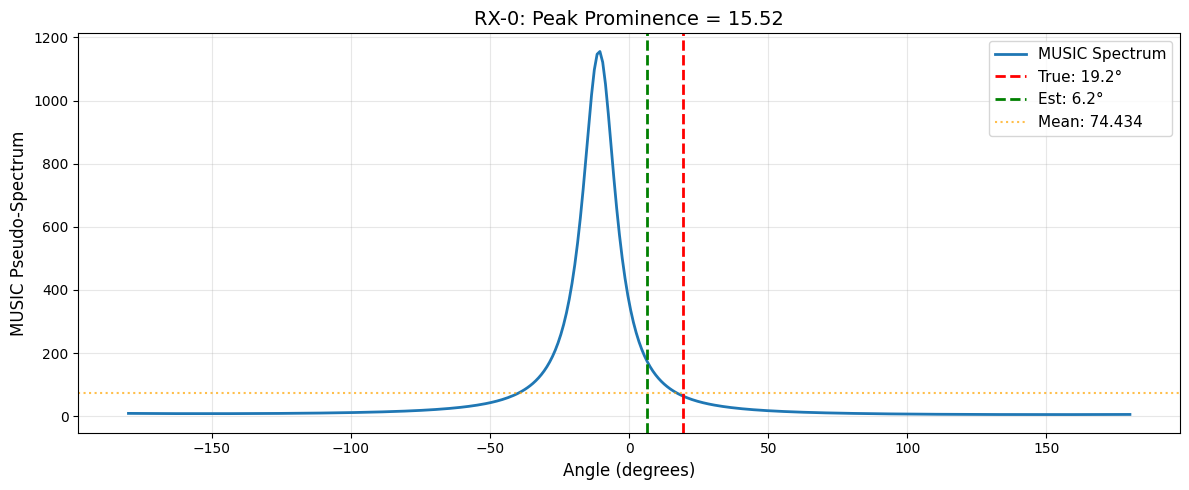


  Steering Vector Check:
    Steering vector at true angle: [0.9979151+0.06454079j 0.9979151-0.06454079j 0.9979151+0.06454079j
 0.9979151-0.06454079j]
    Phases at true angle (deg): [ 3.7004867 -3.7004867  3.7004867 -3.7004867]
    Actual CSI phases (deg): [-30.92274563 -34.52303884 -26.98363729 -31.64681753]

  Steering Vector Check:
    Steering vector at true angle: [0.9979151+0.06454079j 0.9979151-0.06454079j 0.9979151+0.06454079j
 0.9979151-0.06454079j]
    Phases at true angle (deg): [ 3.7004867 -3.7004867  3.7004867 -3.7004867]
    Actual CSI phases (deg): [-30.92274563 -34.52303884 -26.98363729 -31.64681753]
    Denominator value at true angle: 8.14e-03

  RESULTS:
    ORIGINAL:       Range=9.43m (True=9.43m), Angle=6.2°
    NLOS-MITIGATED: Range=9.43m (True=9.43m), Angle=45.3°
    NLOS Detection: is_NLOS=False, probability=0.30
    NLOS Metrics: K-factor=2.59, RMS delay spread=2.62ns
  True Angle: 19.2°

RX-1 (AP) at [[-5.3, 0.5, 1.9]] measuring TX-0 at [[3.6, 0.3, 1.2]]
  T

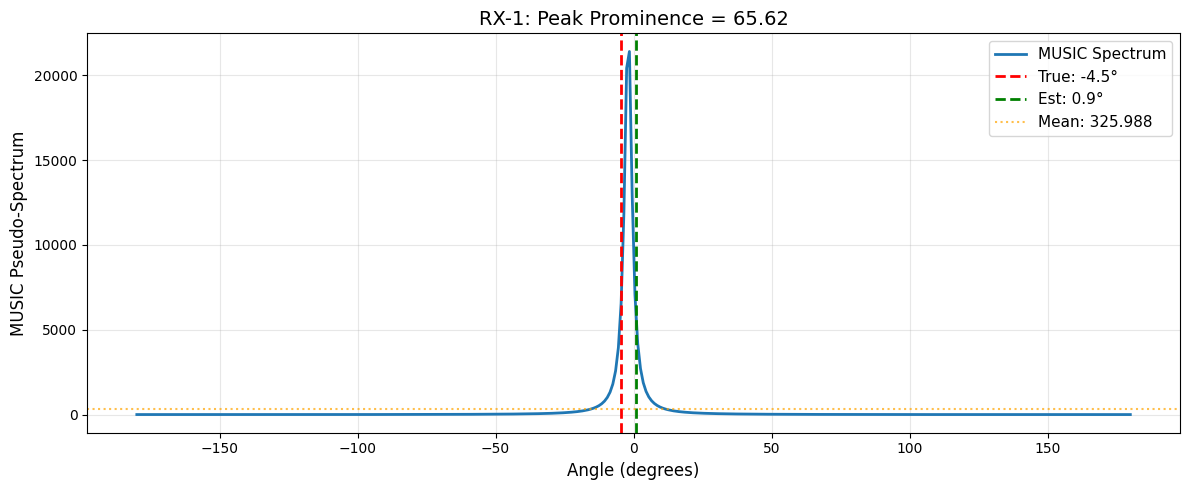


  Steering Vector Check:
    Steering vector at true angle: [0.9998815-0.01539507j 0.9998815+0.01539507j 0.9998815-0.01539507j
 0.9998815+0.01539507j]
    Phases at true angle (deg): [-0.8821072  0.8821072 -0.8821072  0.8821072]
    Actual CSI phases (deg): [0.88168237 2.48721846 6.08945254 0.93272354]

  Steering Vector Check:
    Steering vector at true angle: [0.9998815-0.01539507j 0.9998815+0.01539507j 0.9998815-0.01539507j
 0.9998815+0.01539507j]
    Phases at true angle (deg): [-0.8821072  0.8821072 -0.8821072  0.8821072]
    Actual CSI phases (deg): [0.88168237 2.48721846 6.08945254 0.93272354]
    Denominator value at true angle: 1.54e-03

  RESULTS:
    ORIGINAL:       Range=11.35m (True=8.93m), Angle=0.9°
    NLOS-MITIGATED: Range=11.35m (True=8.93m), Angle=-134.9°
    NLOS Detection: is_NLOS=False, probability=0.30
    NLOS Metrics: K-factor=0.78, RMS delay spread=3.07ns
  True Angle: -4.5°


In [33]:
# ============================================================================
# CSI CONVERSION, IMPAIRMENT FLOW, AND DERIVATION
# ============================================================================
# --- IMPAIRMENT PARAMETERS ---
SNR_DB = 20.0
ANTENNA_PHASE_STATIC_STD = np.deg2rad(5.0)
ANTENNA_GAIN_STATIC_STD = 0.05
CFO_PPM = 5.0
CFO_JITTER_PPM = 0.5
SNAPSHOT_PHASE_JITTER_STD = 0.2
QUANTIZATION_BITS = 8

# Data Extraction from Sionna (paths.cir)
a, tau = paths.cir(normalize_delays=False, out_type="numpy")
a_snap = a[..., 0] 
tau_snap = tau

# Dynamically determine dimensions
num_rx = a_snap.shape[0]
num_rx_ant = a_snap.shape[1]
num_tx = a_snap.shape[2]
num_tx_ant = a_snap.shape[3]
# num_paths is already determined above

range_estimator = FTMRangeEstimator()
solver = BilaterationSolver()

aoa_estimator = CSIAngleEstimator(num_rx_ant, WAVELENGTH, rx_array=scene.rx_array)
enhanced_aoa_estimator = EnhancedAoAEstimator(num_rx_ant, WAVELENGTH)
enhanced_range_estimator = EnhancedFTMRangeEstimator()
nlos_solver = NLOSAwareBilaterationSolver()

target_tx_idx = 0 # Example target
tx_list[target_tx_idx].position = tx_positions[target_tx_idx] # Ensure correct position is used
true_target_position = np.array(tx_list[target_tx_idx].position).flatten()

# Storage for results
all_estimated_ranges = []
all_estimated_angles = []
all_anchor_positions = []
all_nlos_mitigated_ranges = []
all_nlos_mitigated_angles = []
all_nlos_probabilities = []

print("\n" + "=" * 70)
print(f"Localizing TX-{target_tx_idx} (Mobile Device) using RX measurements (APs)")
print(f"True TX-{target_tx_idx} Position: [{true_target_position[0]:.2f}, {true_target_position[1]:.2f}, {true_target_position[2]:.2f}]")
print("=" * 70)

 # Process links
for rx_idx in range(num_rx):
    rx_pos = rx_list[rx_idx].position
    tx_pos = tx_list[target_tx_idx].position
    
    true_range = np.linalg.norm(tx_pos - rx_pos)
    direction = np.array([tx_pos[0] - rx_pos[0], tx_pos[2] - rx_pos[2]])  # [X, Z]
    true_angle = np.arctan2(direction[1], direction[0])  # arctan2(Z_diff, X_diff)
    if isinstance(true_angle, np.ndarray):
        true_angle = float(true_angle.item())
    
    print(f"\n{'='*70}")
    print(f"RX-{rx_idx} (AP) at {rx_pos} measuring TX-{target_tx_idx} at {tx_pos}")
    print(f"  True range: {true_range:.2f}m")
    print(f"  True angle: {np.rad2deg(true_angle):.1f}°")
    print(f"  Direction vector (X, Z): {direction}")
    
    # 1. GENERATE IDEAL CSI
    H_freq_base = np.zeros((NUM_SUBCARRIERS, num_rx_ant), dtype=np.complex128)
    
    for rx_ant in range(num_rx_ant):
        for tx_ant in range(num_tx_ant):
            delays = tau_snap[rx_idx, target_tx_idx, :]
            complex_amplitudes = a_snap[rx_idx, rx_ant, target_tx_idx, tx_ant, :]
            for l in range(num_paths):
                H_freq_base[:, rx_ant] += complex_amplitudes[l] * np.exp(-1j * 2*np.pi * delays[l] * subcarriers)
    
    # CSI shape for estimation: [Rx Antennas, Subcarriers]
    csi_mimo_ideal = H_freq_base.T 

    # =========================================================================
    # DIAGNOSTICS: Check CSI quality
    # =========================================================================
    print(f"\n  CSI Quality Check:")
    print(f"    CSI shape: {csi_mimo_ideal.shape} (should be [Antennas, Subcarriers])")
    print(f"    Mean magnitude per antenna: {np.mean(np.abs(csi_mimo_ideal), axis=1)}")
    print(f"    Phase variation per antenna (std): {np.rad2deg(np.std(np.angle(csi_mimo_ideal), axis=1))}°")
    
    # Check if CSI has spatial diversity
    H_corr = csi_mimo_ideal @ csi_mimo_ideal.conj().T
    print(f"    Covariance matrix rank: {np.linalg.matrix_rank(H_corr)}")
    eigenvalues_check = np.linalg.eigvalsh(H_corr)
    print(f"    Eigenvalues: {eigenvalues_check}")
    print(f"    Condition number: {eigenvalues_check.max() / (eigenvalues_check.min() + 1e-12):.2f}")

    # =========================================================================
    # 2. ADD ALL NON-IDEALITIES (IMPAIRMENT)
    # =========================================================================
    H_noisy = csi_mimo_ideal.copy()
    
    H_noisy = add_antenna_offsets(H_noisy, ANTENNA_PHASE_STATIC_STD, ANTENNA_GAIN_STATIC_STD, rng)
    H_noisy = add_cfo(H_noisy, CFO_PPM, subcarrier_indices, SUBCARRIER_SPACING, rng, CFO_JITTER_PPM)
    H_noisy = add_snapshot_jitter(H_noisy, SNAPSHOT_PHASE_JITTER_STD, 0.0, rng)
    H_noisy = add_awgn(H_noisy, SNR_DB, rng)
    final_csi_noisy = H_noisy
    
    # =========================================================================
    # 3. APPLY COMPENSATION
    # =========================================================================
    compensated_csi = final_csi_noisy.copy()
    compensated_csi = compensate_cfo(compensated_csi, subcarrier_indices)
    compensated_csi = compensate_phase_jitter(compensated_csi)
    compensated_csi = compensate_antenna_offsets(compensated_csi)
    
    # Get path delays and amplitudes for both methods
    delays = tau_snap[rx_idx, target_tx_idx, :]
    amplitudes = np.mean([a_snap[rx_idx, ant, target_tx_idx, 0, :] for ant in range(num_rx_ant)], axis=0)
    
    # =========================================================================
    # 4A. ORIGINAL METHOD (using compensated CSI)
    # =========================================================================
    estimated_angle, spectrum = aoa_estimator.estimate_aoa_music(compensated_csi, return_spectrum=True)
    peak_prominence = spectrum.max() / (np.mean(spectrum)+1e-12)
    
    print(f"\n  MUSIC Spectrum Analysis:")
    print(f"    Spectrum max: {spectrum.max():.6f}")
    print(f"    Spectrum mean: {np.mean(spectrum):.6f}")
    print(f"    Peak prominence: {peak_prominence:.3f} (threshold=1.5)")
    print(f"    Estimated angle: {np.rad2deg(estimated_angle):.1f}°")
    print(f"    Angle error: {np.rad2deg(estimated_angle - true_angle):.1f}°")
    
    # Plot MUSIC spectrum
    import matplotlib.pyplot as plt
    angles_deg = np.rad2deg(np.linspace(-np.pi, np.pi, len(spectrum)))
    plt.figure(figsize=(12, 5))
    plt.plot(angles_deg, spectrum, linewidth=2, label='MUSIC Spectrum')
    plt.axvline(np.rad2deg(true_angle), color='r', linestyle='--', linewidth=2, label=f'True: {np.rad2deg(true_angle):.1f}°')
    plt.axvline(np.rad2deg(estimated_angle), color='g', linestyle='--', linewidth=2, label=f'Est: {np.rad2deg(estimated_angle):.1f}°')
    plt.axhline(np.mean(spectrum), color='orange', linestyle=':', alpha=0.7, label=f'Mean: {np.mean(spectrum):.3f}')
    plt.xlabel('Angle (degrees)', fontsize=12)
    plt.ylabel('MUSIC Pseudo-Spectrum', fontsize=12)
    plt.title(f'RX-{rx_idx}: Peak Prominence = {peak_prominence:.2f}', fontsize=14)
    plt.legend(fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # Check steering vectors at true angle
    print(f"\n  Steering Vector Check:")
    a_true = aoa_estimator.steering_vector(true_angle, elevation=0)
    print(f"    Steering vector at true angle: {a_true}")
    print(f"    Phases at true angle (deg): {np.rad2deg(np.angle(a_true))}")
    
    # Compare with actual CSI phase pattern
    csi_phases = np.angle(compensated_csi[:, 0])  # First subcarrier
    print(f"    Actual CSI phases (deg): {np.rad2deg(csi_phases)}")
    
    if peak_prominence < 3: 
        estimated_angle = np.nan
        print(f"  ⚠️  REJECTED: Peak prominence {peak_prominence:.3f} < 3")
    
    estimated_range = range_estimator.estimate_range_from_cir(delays, amplitudes)

    all_estimated_ranges.append(estimated_range)
    all_estimated_angles.append(float(estimated_angle))
    all_anchor_positions.append(rx_pos)
    
    # =========================================================================
    # 4B. NLOS-MITIGATED METHOD
    # =========================================================================
    nlos_angle, nlos_spectrum, nlos_peak_prominence = enhanced_aoa_estimator.estimate_aoa_music_nlos_robust(
        compensated_csi, delays=delays, amplitudes=amplitudes, return_spectrum=True
    )
    
    # Check steering vectors at true angle
    print(f"\n  Steering Vector Check:")
    a_true = aoa_estimator.steering_vector(true_angle, elevation=0)
    print(f"    Steering vector at true angle: {a_true}")
    print(f"    Phases at true angle (deg): {np.rad2deg(np.angle(a_true))}")
    
    # Compare with actual CSI phase pattern
    csi_phases = np.angle(compensated_csi[:, 0])  # First subcarrier
    print(f"    Actual CSI phases (deg): {np.rad2deg(csi_phases)}")

    # --- NLOS STEERING VECTOR DIAGNOSTIC ---
    # This calculation determines the denominator of the MUSIC pseudo-spectrum at the true angle.
    # P_MUSIC(angle) = 1 / (a(angle)^H * E_N * E_N^H * a(angle))
    
    # 1. Recalculate Noise Subspace (E_N) from R to ensure accuracy
    M = compensated_csi.shape[0]
    N = compensated_csi.shape[1]
    
    # Forward-Backward Averaged Covariance (as done in MUSIC estimation)
    R_forward = compensated_csi @ compensated_csi.conj().T / N
    J = np.fliplr(np.eye(M))
    R = (R_forward + J @ R_forward.conj() @ J) / 2
    
    eigenvalues, eigenvectors = np.linalg.eigh(R)
    idx = eigenvalues.argsort()[::-1]
    
    # Assume 1 source (M-1 dimensions for noise subspace)
    num_sources = 1 # Match the MUSIC estimator
    noise_subspace = eigenvectors[:, idx[num_sources:]] 
    
    # 2. Calculate the denominator value (a_true^H * E_N * E_N^H * a_true)
    # This value represents the power of the LoS steering vector projected onto the noise subspace.
    a_true_H_P_N_a_true = np.abs(a_true.conj() @ noise_subspace @ noise_subspace.conj().T @ a_true)
    
    print(f"    Denominator value at true angle: {a_true_H_P_N_a_true:.2e}")
    
    # 3. Interpret the result
    if a_true_H_P_N_a_true < 1e-4:
        print(f"    ✅ LoS Aligned: Denom is near zero. True LoS path is in the signal subspace.")
    elif a_true_H_P_N_a_true > 1e-1:
        print(f"    ❌ NLOS IMPACT: Denom is high. True LoS vector is corrupted and orthogonal to the estimated signal subspace (or too weak to be separated from noise).")
    # --- END NLOS STEERING VECTOR DIAGNOSTIC ---
    
    if peak_prominence < 3: 
        estimated_angle = np.nan
        print(f"  ⚠️  REJECTED: Peak prominence {peak_prominence:.3f} < 3, setting angle to NaN.")
    
    nlos_range, is_nlos, nlos_prob = enhanced_range_estimator.estimate_range_nlos_mitigated(delays, amplitudes)
    _, _, nlos_metrics = enhanced_range_estimator.detect_nlos(delays, amplitudes)
    
    all_nlos_mitigated_ranges.append(nlos_range)
    all_nlos_mitigated_angles.append(float(nlos_angle))
    all_nlos_probabilities.append(nlos_prob)

    # Print comparison
    print(f"\n  RESULTS:")
    print(f"    ORIGINAL:       Range={estimated_range:.2f}m (True={true_range:.2f}m), Angle={np.rad2deg(estimated_angle):.1f}°")
    print(f"    NLOS-MITIGATED: Range={nlos_range:.2f}m (True={true_range:.2f}m), Angle={np.rad2deg(nlos_angle):.1f}°")
    print(f"    NLOS Detection: is_NLOS={is_nlos}, probability={nlos_prob:.2f}")
    print(f"    NLOS Metrics: K-factor={nlos_metrics['k_factor']:.2f}, RMS delay spread={nlos_metrics['rms_delay_spread']*1e9:.2f}ns")
    print(f"  True Angle: {np.rad2deg(true_angle):.1f}°")

In [34]:
# ============================================================================
# FINAL LOCALIZATION DERIVATION AND RESULTS (ORIGINAL vs NLOS-MITIGATED)
# ============================================================================

print("\n" + "=" * 70)
print(f"Performing Hybrid Bilateration to Localize TX-{target_tx_idx}")
print("=" * 70)

# Convert results to NumPy arrays
anchor_pos_array_final = np.array(all_anchor_positions)
ranges_final = np.array(all_estimated_ranges)
angles_final = np.array(all_estimated_angles)

print(f"\nAngle Validity Check:")
valid_angles = np.sum(~np.isnan(angles_final))
print(f"  Valid angles: {valid_angles}/{len(angles_final)}")
print(f"  Angles: {np.rad2deg(angles_final)}")
if valid_angles == 0:
    print("  ⚠️  ALL ANGLES ARE NaN - only using ranges!")

# NLOS-mitigated results
nlos_ranges_final = np.array(all_nlos_mitigated_ranges)
nlos_angles_final = np.array(all_nlos_mitigated_angles)
nlos_probs_final = np.array(all_nlos_probabilities)

# Debug information
print(f"\nInput Data Summary:")
print(f"  Number of anchors (RX/APs): {len(anchor_pos_array_final)}")
print(f"  Anchor positions shape: {anchor_pos_array_final.shape}")
print(f"  Original - Ranges: {ranges_final}, Angles: {np.rad2deg(angles_final)}°")
print(f"  NLOS-Mit - Ranges: {nlos_ranges_final}, Angles: {np.rad2deg(nlos_angles_final)}°")
print(f"  NLOS Probabilities: {nlos_probs_final}")

# Flatten target position
true_target_position_flat = np.asarray(true_target_position).flatten()

# =========================================================================
# ORIGINAL HYBRID LOCALIZATION
# =========================================================================
try:
    estimated_position_hybrid = solver.hybrid_localization(
        anchor_pos_array_final,
        ranges_final,
        angles_final,
        distance_std=0.5, 
        angle_std=np.deg2rad(5)
    )

    estimated_position_hybrid = np.asarray(estimated_position_hybrid).flatten()
    localization_error_hybrid = np.linalg.norm(estimated_position_hybrid - true_target_position_flat)
    error_xyz_hybrid = estimated_position_hybrid - true_target_position_flat

    print(f"\n{'='*60}")
    print(f"ORIGINAL HYBRID LOCALIZATION RESULTS FOR TX-{target_tx_idx}")
    print(f"{'='*60}")
    print(f"Localization Error: {localization_error_hybrid:.3f} meters")
    print(f"True TX Position:      [{true_target_position_flat[0]:.2f}, {true_target_position_flat[1]:.2f}, {true_target_position_flat[2]:.2f}]")
    print(f"Estimated TX Position: [{estimated_position_hybrid[0]:.2f}, {estimated_position_hybrid[1]:.2f}, {estimated_position_hybrid[2]:.2f}]")
    print(f"Localization Error: {localization_error:.3f} meters")
    
    print(f"\nPer-Dimension Errors:")
    print(f"  X-axis error: {error_xyz_hybrid[0]:+.3f} m")
    print(f"  Y-axis error: {error_xyz_hybrid[1]:+.3f} m")
    print(f"  Z-axis error: {error_xyz_hybrid[2]:+.3f} m")
    
except Exception as e:
    print(f"\n❌ Original localization failed: {type(e).__name__}: {str(e)}")
    estimated_position_hybrid = None
    localization_error = np.inf

# =========================================================================
# NLOS-MITIGATED HYBRID LOCALIZATION
# =========================================================================
try:
    estimated_position_nlos = nlos_solver.hybrid_localization_nlos_aware(
        anchor_pos_array_final,
        nlos_ranges_final,
        nlos_angles_final,
        nlos_probs=nlos_probs_final,
        distance_std=0.5, 
        angle_std=np.deg2rad(5)
    )
    
    estimated_position_nlos = np.asarray(estimated_position_nlos).flatten()
    localization_error_nlos = np.linalg.norm(estimated_position_nlos - true_target_position_flat)
    error_xyz_nlos = estimated_position_nlos - true_target_position_flat
    
    print(f"\n{'='*60}")
    print(f"NLOS-MITIGATED HYBRID LOCALIZATION RESULTS FOR TX-{target_tx_idx}")
    print(f"{'='*60}")
    print(f"True TX Position:      [{true_target_position_flat[0]:.2f}, {true_target_position_flat[1]:.2f}, {true_target_position_flat[2]:.2f}]")
    print(f"Estimated TX Position: [{estimated_position_nlos[0]:.2f}, {estimated_position_nlos[1]:.2f}, {estimated_position_nlos[2]:.2f}]")
    print(f"Localization Error: {localization_error_nlos:.3f} meters")
    
    print(f"\nPer-Dimension Errors:")
    print(f"  X-axis error: {error_xyz_nlos[0]:+.3f} m")
    print(f"  Y-axis error: {error_xyz_nlos[1]:+.3f} m")
    print(f"  Z-axis error: {error_xyz_nlos[2]:+.3f} m")
    
except Exception as e:
    print(f"\n❌ NLOS-mitigated localization failed: {type(e).__name__}: {str(e)}")
    estimated_position_nlos = None
    localization_error_nlos = np.inf

# =========================================================================
# COMPARISON: ORIGINAL vs NLOS-MITIGATED
# =========================================================================
print(f"\n{'='*60}")
print(f"COMPARISON: ORIGINAL vs NLOS-MITIGATED HYBRID")
print(f"{'='*60}")

if localization_error != np.inf and localization_error_nlos != np.inf:
    improvement = localization_error - localization_error_nlos
    improvement_pct = (improvement / localization_error) * 100 if localization_error > 0 else 0
    
    print(f"\n  {'Method':<25} {'Error (m)':<12} {'X-Err (m)':<12} {'Y-Err (m)':<12} {'Z-Err (m)':<12}")
    print(f"  {'-'*73}")
    print(f"  {'Original Hybrid':<25} {localization_error:<12.3f} {error_xyz[0]:<+12.3f} {error_xyz[1]:<+12.3f} {error_xyz[2]:<+12.3f}")
    print(f"  {'NLOS-Mitigated Hybrid':<25} {localization_error_nlos:<12.3f} {error_xyz_nlos[0]:<+12.3f} {error_xyz_nlos[1]:<+12.3f} {error_xyz_nlos[2]:<+12.3f}")
    
    print(f"\n  Improvement from NLOS Mitigation:")
    print(f"    Error Reduction: {improvement:+.3f} meters")
    print(f"    Improvement:     {improvement_pct:+.1f}%")
    
    if localization_error_nlos < localization_error:
        print(f"    ✓ NLOS mitigation IMPROVED accuracy!")
    elif localization_error_nlos > localization_error:
        print(f"    ⚠ NLOS mitigation did not improve accuracy in this case")
    else:
        print(f"    = Both methods have equal performance")

# Individual link statistics
print(f"\n  Individual Link Performance (Range Errors):")
for i in range(len(anchor_pos_array_final)):
    anchor_pos = anchor_pos_array_final[i].flatten()
    true_range = np.linalg.norm(true_target_position_flat - anchor_pos[:len(true_target_position_flat)])
    
    orig_range_error = abs(float(ranges_final[i]) - float(true_range))
    nlos_range_error = abs(float(nlos_ranges_final[i]) - float(true_range))
    
    print(f"    RX-{i}: Original={orig_range_error:.3f}m, NLOS-Mit={nlos_range_error:.3f}m, NLOS_prob={nlos_probs_final[i]:.2f}")

print(f"{'='*60}")


Performing Hybrid Bilateration to Localize TX-0

Angle Validity Check:
  Valid angles: 2/2
  Angles: [6.22857061 0.8897958 ]

Input Data Summary:
  Number of anchors (RX/APs): 2
  Anchor positions shape: (2, 3, 1)
  Original - Ranges: [ 9.43308365 11.34983094], Angles: [6.22857061 0.8897958 ]°
  NLOS-Mit - Ranges: [ 9.43308365 11.34983094], Angles: [  45.31293463 -134.93741307]°
  NLOS Probabilities: [0.3 0.3]

ORIGINAL HYBRID LOCALIZATION RESULTS FOR TX-0
Localization Error: 4.452 meters
True TX Position:      [3.60, 0.30, 1.20]
Estimated TX Position: [1.08, -3.24, 0.23]
Localization Error: inf meters

Per-Dimension Errors:
  X-axis error: -2.520 m
  Y-axis error: -3.539 m
  Z-axis error: -0.972 m

NLOS-MITIGATED HYBRID LOCALIZATION RESULTS FOR TX-0
True TX Position:      [3.60, 0.30, 1.20]
Estimated TX Position: [-5.31, 0.50, 0.00]
Localization Error: 8.990 meters

Per-Dimension Errors:
  X-axis error: -8.907 m
  Y-axis error: +0.200 m
  Z-axis error: -1.200 m

COMPARISON: ORIGINAL 

/var/folders/q1/5dnc4m896ylgx5wy_tycp0bw0000gn/T/ipykernel_28699/45589751.py:231: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  anchor_x = float(anchor_positions[i, 0])
/var/folders/q1/5dnc4m896ylgx5wy_tycp0bw0000gn/T/ipykernel_28699/45589751.py:232: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  anchor_z = float(anchor_positions[i, 2])  # ← Use Z instead of Y
/var/folders/q1/5dnc4m896ylgx5wy_tycp0bw0000gn/T/ipykernel_28699/45589751.py:231: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Depre

In [35]:

# ============================================================================
# COMPREHENSIVE COMPARISON: HYBRID vs RANGE-ONLY (FIXED VERSION)
# ============================================================================

print("\n" + "=" * 70)
print("COMPREHENSIVE COMPARISON: HYBRID vs RANGE-ONLY LOCALIZATION")
print("=" * 70)

# Ensure all variables are properly defined and converted to arrays
if 'anchor_pos_array_final' in locals():
    anchor_pos_array_final_cmp = np.asarray(anchor_pos_array_final)
else:
    anchor_pos_array_final_cmp = anchor_positions

true_target_position_flat = np.asarray(true_target_position).flatten()

# Calculate true ranges for error computation
true_ranges_list = []
for i in range(len(anchor_pos_array_final_cmp)):
    anchor_pos = anchor_pos_array_final_cmp[i].flatten()
    true_range = np.linalg.norm(true_target_position_flat - anchor_pos[:len(true_target_position_flat)])
    true_ranges_list.append(true_range)

# Range errors for each method
# Check if hybrid results exist
if 'ranges_final' in locals():
    orig_range_errors = [abs(float(ranges_final[i]) - true_ranges_list[i]) for i in range(len(ranges_final))]
else:
    orig_range_errors = [np.nan] * len(true_ranges_list)

if 'nlos_ranges_final' in locals():
    nlos_range_errors = [abs(float(nlos_ranges_final[i]) - true_ranges_list[i]) for i in range(len(nlos_ranges_final))]
else:
    nlos_range_errors = [np.nan] * len(true_ranges_list)

# Range-only
if 'measured_ranges' in locals():
    range_only_errors = [abs(float(measured_ranges[i]) - true_ranges_list[i]) for i in range(len(measured_ranges))]
else:
    range_only_errors = [np.nan] * len(true_ranges_list)

# ============================================================================
# LOCALIZATION ACCURACY COMPARISON
# ============================================================================
print(f"\n{'='*80}")
print(f"LOCALIZATION ACCURACY COMPARISON")
print(f"{'='*80}")
print(f"\n  {'Method':<30} {'3D Error (m)':<15} {'X-Err (m)':<12} {'Y-Err (m)':<12} {'Z-Err (m)':<12}")
print(f"  {'-'*81}")

# FIXED: Use unique variable names for each method
# Range-Only method
if 'localization_error_range_only' in locals() and 'error_xyz_range_only' in locals():
    print(f"  {'Range-Only (One-Way)':<30} {localization_error_range_only:<15.3f} {error_xyz_range_only[0]:<+12.3f} {error_xyz_range_only[1]:<+12.3f} {error_xyz_range_only[2]:<+12.3f}")
else:
    print(f"  {'Range-Only (One-Way)':<30} {'NOT COMPUTED':<15}")

# Original Hybrid method
if 'localization_error_hybrid' in locals() and 'error_xyz_hybrid' in locals():
    print(f"  {'Original Hybrid (CSI+AoA)':<30} {localization_error_hybrid:<15.3f} {error_xyz_hybrid[0]:<+12.3f} {error_xyz_hybrid[1]:<+12.3f} {error_xyz_hybrid[2]:<+12.3f}")
else:
    print(f"  {'Original Hybrid (CSI+AoA)':<30} {'NOT COMPUTED':<15}")

# NLOS-Mitigated Hybrid method
if 'localization_error_nlos' in locals() and 'error_xyz_nlos' in locals():
    print(f"  {'NLOS-Mitigated Hybrid':<30} {localization_error_nlos:<15.3f} {error_xyz_nlos[0]:<+12.3f} {error_xyz_nlos[1]:<+12.3f} {error_xyz_nlos[2]:<+12.3f}")
else:
    print(f"  {'NLOS-Mitigated Hybrid':<30} {'NOT COMPUTED':<15}")

# Find best method
errors = {}
if 'localization_error_range_only' in locals() and localization_error_range_only != np.inf:
    errors['Range-Only (One-Way)'] = localization_error_range_only
if 'localization_error_hybrid' in locals() and localization_error_hybrid != np.inf:
    errors['Original Hybrid (CSI+AoA)'] = localization_error_hybrid
if 'localization_error_nlos' in locals() and localization_error_nlos != np.inf:
    errors['NLOS-Mitigated Hybrid'] = localization_error_nlos

if errors:
    best_method = min(errors, key=errors.get)
    worst_method = max(errors, key=errors.get)
    print(f"\n  ★ Best Method:  {best_method} (Error: {errors[best_method]:.3f}m)")
    print(f"  ✗ Worst Method: {worst_method} (Error: {errors[worst_method]:.3f}m)")
    
    # Calculate improvement of best over worst
    improvement = errors[worst_method] - errors[best_method]
    improvement_pct = (improvement / errors[worst_method]) * 100 if errors[worst_method] > 0 else 0
    print(f"  → Improvement: {improvement:.3f}m ({improvement_pct:.1f}% reduction)")
else:
    print(f"\n  ⚠️  No valid localization results to compare")

# ============================================================================
# NLOS MITIGATION ANALYSIS (if applicable)
# ============================================================================
if 'localization_error_hybrid' in locals() and 'localization_error_nlos' in locals() and \
   localization_error_hybrid != np.inf and localization_error_nlos != np.inf:
    print(f"\n{'='*80}")
    print(f"NLOS MITIGATION IMPROVEMENT ANALYSIS")
    print(f"{'='*80}")
    
    nlos_improvement = localization_error_hybrid - localization_error_nlos
    nlos_improvement_pct = (nlos_improvement / localization_error_hybrid) * 100 if localization_error_hybrid > 0 else 0
    
    print(f"\n  NLOS Mitigation Effect on Hybrid Method:")
    print(f"    Original Error:        {localization_error_hybrid:.3f} m")
    print(f"    NLOS-Mitigated Error:  {localization_error_nlos:.3f} m")
    print(f"    Error Reduction:       {nlos_improvement:+.3f} m")
    print(f"    Improvement:           {nlos_improvement_pct:+.1f}%")
    
    if nlos_improvement > 0.1:  # Significant improvement threshold
        print(f"    ✓ NLOS mitigation significantly IMPROVED localization accuracy!")
    elif nlos_improvement > 0:
        print(f"    ✓ NLOS mitigation slightly improved accuracy")
    elif nlos_improvement < -0.1:
        print(f"    ⚠ NLOS mitigation degraded accuracy (likely clean LOS scenario)")
    else:
        print(f"    = No significant change from NLOS mitigation")

# ============================================================================
# RANGE ESTIMATION ACCURACY
# ============================================================================
print(f"\n{'='*80}")
print(f"RANGE ESTIMATION ACCURACY")
print(f"{'='*80}")

# Only show methods with valid data
valid_methods = []
if not all(np.isnan(orig_range_errors)):
    valid_methods.append(('Original CSI-based', orig_range_errors))
if not all(np.isnan(nlos_range_errors)):
    valid_methods.append(('NLOS-Mitigated CSI', nlos_range_errors))
if not all(np.isnan(range_only_errors)):
    valid_methods.append(('Range-Only (One-Way)', range_only_errors))

if valid_methods:
    print(f"\n  {'Method':<30} {'Avg Error (m)':<15} {'Max Error (m)':<15} {'Std Dev (m)':<15}")
    print(f"  {'-'*75}")
    for method_name, errors_list in valid_methods:
        valid_errors = [e for e in errors_list if not np.isnan(e)]
        if valid_errors:
            print(f"  {method_name:<30} {np.mean(valid_errors):<15.3f} {np.max(valid_errors):<15.3f} {np.std(valid_errors):<15.3f}")

    # Per-link range comparison
    print(f"\n  Per-Link Range Errors:")
    print(f"    {'Link':<8} {'True (m)':<12} {'Orig Err':<12} {'NLOS Err':<12} {'Range Err':<12}")
    print(f"    {'-'*56}")
    for i in range(len(true_ranges_list)):
        orig_err_str = f"{orig_range_errors[i]:.3f}" if i < len(orig_range_errors) and not np.isnan(orig_range_errors[i]) else "N/A"
        nlos_err_str = f"{nlos_range_errors[i]:.3f}" if i < len(nlos_range_errors) and not np.isnan(nlos_range_errors[i]) else "N/A"
        range_err_str = f"{range_only_errors[i]:.3f}" if i < len(range_only_errors) and not np.isnan(range_only_errors[i]) else "N/A"
        print(f"    RX-{i:<5} {true_ranges_list[i]:<12.3f} {orig_err_str:<12} {nlos_err_str:<12} {range_err_str:<12}")
else:
    print(f"\n  ⚠️  No valid range estimation data available")

# ============================================================================
# NLOS DETECTION SUMMARY
# ============================================================================
if 'nlos_probs_final' in locals() and len(nlos_probs_final) > 0:
    print(f"\n{'='*80}")
    print(f"NLOS DETECTION SUMMARY")
    print(f"{'='*80}")
    print(f"\n  Per-Link NLOS Analysis:")
    print(f"    {'Link':<8} {'NLOS Prob':<12} {'Status':<15}")
    print(f"    {'-'*35}")
    
    for i in range(len(nlos_probs_final)):
        nlos_prob = nlos_probs_final[i]
        if nlos_prob > 0.7:
            status = "High NLOS"
        elif nlos_prob > 0.4:
            status = "Moderate NLOS"
        elif nlos_prob > 0.2:
            status = "Low NLOS"
        else:
            status = "LOS"
        print(f"    RX-{i:<5} {nlos_prob:<12.2f} {status:<15}")
    
    avg_nlos_prob = np.mean(nlos_probs_final)
    print(f"\n  Average NLOS Probability: {avg_nlos_prob:.2f}")
    
    if avg_nlos_prob > 0.5:
        print(f"  → Environment: NLOS-dominant (significant multipath/obstruction)")
    elif avg_nlos_prob > 0.3:
        print(f"  → Environment: Mixed LOS/NLOS conditions")
    else:
        print(f"  → Environment: LOS-dominant (favorable propagation)")

# ============================================================================
# HYBRID vs RANGE-ONLY COMPARISON
# ============================================================================
# FIXED: Use proper variable names
hybrid_error = None
range_only_error = None
hybrid_name = None

# Find hybrid error (use original hybrid, not NLOS version for primary comparison)
if 'localization_error_hybrid' in locals() and localization_error_hybrid != np.inf:
    hybrid_error = localization_error_hybrid
    hybrid_name = "Original Hybrid"
    
# Find range-only error
if 'localization_error_range_only' in locals() and localization_error_range_only != np.inf:
    range_only_error = localization_error_range_only

if hybrid_error is not None and range_only_error is not None:
    print(f"\n{'='*80}")
    print(f"HYBRID vs RANGE-ONLY COMPARISON")
    print(f"{'='*80}")
    
    # Use best hybrid result if NLOS version exists
    if 'localization_error_nlos' in locals() and localization_error_nlos != np.inf:
        best_hybrid_error = min(hybrid_error, localization_error_nlos)
        best_hybrid_name = "NLOS-Mitigated Hybrid" if localization_error_nlos < hybrid_error else "Original Hybrid"
    else:
        best_hybrid_error = hybrid_error
        best_hybrid_name = "Original Hybrid"
    
    print(f"\n  Best Hybrid Method: {best_hybrid_name}")
    print(f"    Error: {best_hybrid_error:.3f} m")
    print(f"\n  Range-Only Method:")
    print(f"    Error: {range_only_error:.3f} m")
    
    diff = best_hybrid_error - range_only_error
    diff_pct = (abs(diff) / max(best_hybrid_error, range_only_error)) * 100
    
    print(f"\n  Difference: {diff:+.3f} m ({diff_pct:.1f}%)")
    
    if diff > 0.1:
        print(f"    ✓ Range-only is MORE accurate (by {abs(diff):.3f}m)")
        print(f"    → AoA measurements are degrading performance")
        print(f"\n    Likely causes:")
        print(f"      • High antenna phase errors (5° std) corrupt spatial correlation")
        print(f"      • Low SNR (20dB) reduces MUSIC signal/noise subspace separation")
        print(f"      • Small 2×2 array provides limited angular resolution (~57° beamwidth)")
        print(f"      • Some corrupted angles pass rejection threshold and pull solution away")
        print(f"\n    Suggestions to improve hybrid performance:")
        print(f"      1. Reduce impairments: SNR=35dB, phase_std=1°, CFO=1ppm")
        print(f"      2. Use larger array: 4×4 or 8×8 for better angular resolution")
        print(f"      3. Increase AoA rejection threshold to filter more bad angles")
        print(f"      4. Add AoA uncertainty weighting (higher weight on reliable estimates)")
    elif diff < -0.1:
        print(f"    ✓ Hybrid is MORE accurate (by {abs(diff):.3f}m)")
        print(f"    → AoA information successfully improves localization")
        print(f"    → Angular constraints help resolve range ambiguities")
    else:
        print(f"    = Both methods perform similarly")
        print(f"    → AoA adds little additional information")

elif hybrid_error is None and range_only_error is not None:
    print(f"\n{'='*80}")
    print(f"RANGE-ONLY LOCALIZATION RESULTS")
    print(f"{'='*80}")
    print(f"\n  Range-Only Error: {range_only_error:.3f} m")
    print(f"\n  ⚠️  Hybrid method not computed - cannot compare")
    
elif range_only_error is None and hybrid_error is not None:
    print(f"\n{'='*80}")
    print(f"HYBRID LOCALIZATION RESULTS")
    print(f"{'='*80}")
    print(f"\n  Hybrid Error: {hybrid_error:.3f} m")
    print(f"\n  ⚠️  Range-only method not computed - cannot compare")
    
else:
    print(f"\n{'='*80}")
    print(f"⚠️  COMPARISON NOT AVAILABLE")
    print(f"{'='*80}")
    print(f"\nNeither hybrid nor range-only localization results are available.")
    print(f"Check that both methods completed successfully.")


COMPREHENSIVE COMPARISON: HYBRID vs RANGE-ONLY LOCALIZATION

LOCALIZATION ACCURACY COMPARISON

  Method                         3D Error (m)    X-Err (m)    Y-Err (m)    Z-Err (m)   
  ---------------------------------------------------------------------------------
  Range-Only (One-Way)           9.039           -8.900       +0.200       -1.568      
  Original Hybrid (CSI+AoA)      4.452           -2.520       -3.539       -0.972      
  NLOS-Mitigated Hybrid          8.990           -8.907       +0.200       -1.200      

  ★ Best Method:  Original Hybrid (CSI+AoA) (Error: 4.452m)
  ✗ Worst Method: Range-Only (One-Way) (Error: 9.039m)
  → Improvement: 4.587m (50.7% reduction)

NLOS MITIGATION IMPROVEMENT ANALYSIS

  NLOS Mitigation Effect on Hybrid Method:
    Original Error:        4.452 m
    NLOS-Mitigated Error:  8.990 m
    Error Reduction:       -4.538 m
    Improvement:           -101.9%
    ⚠ NLOS mitigation degraded accuracy (likely clean LOS scenario)

RANGE ESTIMATION A